In [2]:
import scvelo as scv
import scanpy as sc
import velocyto as vcy
import cellrank as cr
import loompy as lp

from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad

import matplotlib.pyplot as plt

import os
import sys
import logging

In [15]:
# load file path from ocean
adata_infile = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/All_Cell_Types.h5ad'
adata_infile_fiber = '/ocean/projects/cis240075p/asachan/datasets/SKM_multimodal_ageing/objects/scsn/Myofiber_scsn_RNA.h5ad'


In [18]:
# transfer the file to the scratch space
!rsync -aP $adata_infile /dev/shm/

sending incremental file list
All_Cell_Types.h5ad
  8,365,646,904 100%  383.19MB/s    0:00:20 (xfr#1, to-chk=0/1)


In [20]:
adata = sc.read_h5ad(os.path.join('/dev/shm/', os.path.basename(adata_infile)))

In [21]:
adata

AnnData object with n_obs × n_vars = 292423 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation'
    var: 'features'
    uns: 'age_pop_colors'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

In [31]:
# Get unique annotation classes
annotation_classes = adata.obs['Annotation'].unique()
annotation_color_dict = {
    'Type I': 'green',
    'Type II': 'lightblue',
    'Adipocyte': 'lightskyblue',
    'Specialized MF': 'darkblue',
    'Myeloid cell': 'yellow',
    'FAP': 'mediumorchid',
    'Lymphocyte': 'teal',
    'MuSC': 'firebrick',
    'Tenocyte': 'limegreen',
    'Endo': 'brown',
    'Pericyte': 'orange',
    'SMC': 'purple',
    'Mast cell': 'lightcoral',
    'Schwann cell': 'dodgerblue',
    'Erythrocyte': 'red'
}

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


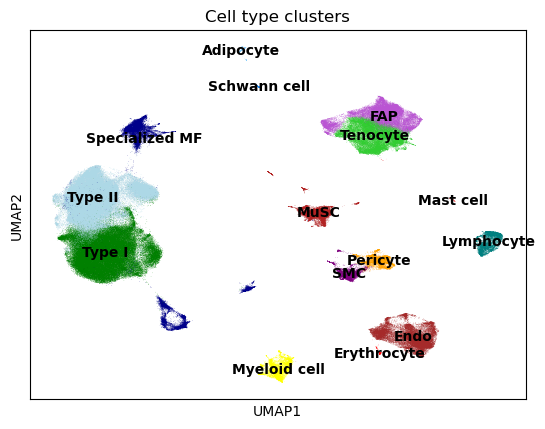

In [34]:
# First, make sure the colors are in the same order as the categories
categories = adata.obs['Annotation'].cat.categories
colors = []
for cat in categories:
    colors.append(annotation_color_dict[cat])

# Set the colors in adata.uns
adata.uns['Annotation_colors'] = colors
# Now plot without specifying color_map
sc.pl.umap(adata, color=['Annotation'], legend_loc='on data', title='Cell type clusters', save='RNA_data.pdf')

/ocean/projects/cis240075p/asachan/.conda/envs/scvelo/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


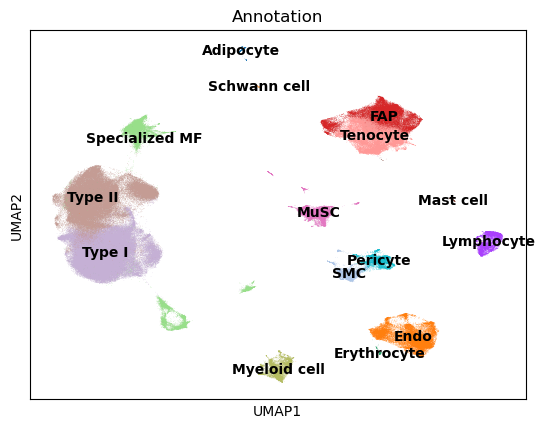

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_cmap', 
    ['#f4cccc', '#5e3370']  # Light pink to dark purple for aging trajectory
)
sc.pl.umap(adata, color=['Annotation'], legend_loc='on data', save='RNA_dataset.pdf')